# Baseball Detection Project

This notebook builds an object detection pipeline for identifying baseballs in training video frames. The workflow includes loading the videos and XML annotations, extracting video frames, converting annotations into a structured dataset, training a Faster R-CNN object detection model, and visualizing prediction results.

**Note:** Training is demonstrated on a subset of the data to ensure the notebook runs efficiently on a local machine while still validating the full object detection pipeline.

#### 1. Import Libraries and Setup
#### 2. Load and Verify Data
#### 3. Extract Frames from Videos
#### 4. Process Annotations
#### 5. Build Dataset
#### 6. Train-Test Split
#### 7. DataLoader Setup
#### 8. Model Setup
#### 9. Training (Demonstration Run)
#### 10. Prediction
#### 11. Visualization of Results

In [1]:
# Import required libraries for file handling, data processing, image processing, visualization, and modeling
from pathlib import Path
import os
import cv2
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from sklearn.model_selection import train_test_split

# Set the main project directory to the current folder where this notebook is stored
PROJECT_DIR = Path.cwd()

# Define folders for videos, annotations, and extracted frames
VIDEOS_DIR = PROJECT_DIR / "videos_final"
ANNOTATIONS_DIR = PROJECT_DIR / "annotations_final"
FRAMES_DIR = PROJECT_DIR / "frames"

# Create frames folder if it does not already exist
FRAMES_DIR.mkdir(exist_ok=True)

# Check that the required folders exist
print("Project folder:", PROJECT_DIR)
print("Videos folder exists:", VIDEOS_DIR.exists())
print("Annotations folder exists:", ANNOTATIONS_DIR.exists())
print("Frames folder exists:", FRAMES_DIR.exists())

Project folder: c:\Business Forecasting\baseball-final-project
Videos folder exists: True
Annotations folder exists: True
Frames folder exists: True


In [2]:
# Collect all video and annotation files
video_files = sorted(VIDEOS_DIR.glob("*.mov"))
annotation_files = sorted(ANNOTATIONS_DIR.glob("*.xml"))

# Compare file names without extensions
video_names = {file.stem for file in video_files}
annotation_names = {file.stem for file in annotation_files}

missing_annotations = sorted(video_names - annotation_names)
extra_annotations = sorted(annotation_names - video_names)

print("Number of videos:", len(video_files))
print("Number of annotations:", len(annotation_files))
print("Missing annotations:", missing_annotations)
print("Extra annotations:", extra_annotations)

Number of videos: 64
Number of annotations: 64
Missing annotations: []
Extra annotations: []


In [3]:
# Function to extract frames from each video and save them as image files
def extract_frames(video_path, output_dir):
    # Open the video file
    cap = cv2.VideoCapture(str(video_path))
    frame_idx = 0

    # Create a separate folder for each video's frames
    video_name = video_path.stem
    video_out_dir = output_dir / video_name
    video_out_dir.mkdir(exist_ok=True)

    # Read and save each frame
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_file = video_out_dir / f"{video_name}_frame_{frame_idx:04d}.jpg"
        cv2.imwrite(str(frame_file), frame)
        frame_idx += 1

    # Close the video file
    cap.release()
    print(f"{video_name}: {frame_idx} frames extracted")


# Extract frames for all videos
for video_path in video_files:
    extract_frames(video_path, FRAMES_DIR)

dusty_1: 76 frames extracted
IMG_0030: 48 frames extracted
IMG_0031: 50 frames extracted
IMG_0032: 51 frames extracted
IMG_0033: 50 frames extracted
IMG_0034: 52 frames extracted
IMG_0035: 52 frames extracted
IMG_0036: 49 frames extracted
IMG_0037: 48 frames extracted
IMG_0038: 51 frames extracted
IMG_0039: 54 frames extracted
IMG_0040: 57 frames extracted
IMG_0041: 50 frames extracted
IMG_0042: 52 frames extracted
IMG_0043: 48 frames extracted
IMG_0044: 56 frames extracted
IMG_0045: 60 frames extracted
IMG_0046: 54 frames extracted
IMG_0047: 48 frames extracted
IMG_0074: 100 frames extracted
IMG_0075: 80 frames extracted
IMG_0076: 59 frames extracted
IMG_0077: 92 frames extracted
IMG_0078: 94 frames extracted
IMG_0079: 80 frames extracted
IMG_0083: 57 frames extracted
IMG_0084: 62 frames extracted
IMG_0085: 42 frames extracted
IMG_0170: 72 frames extracted
IMG_0171: 51 frames extracted
IMG_0172: 69 frames extracted
IMG_7918_dusty: 76 frames extracted
IMG_7919_dusty: 50 frames extracte

In [4]:
# Parse all CVAT XML annotation files into one structured table
all_rows = []

for xml_file in annotation_files:
    tree = ET.parse(xml_file)
    root = tree.getroot()

    for track in root.findall("track"):
        label = track.attrib["label"]
        track_id = track.attrib["id"]

        for box in track.findall("box"):
            # Skip boxes that are marked as outside the frame
            if box.attrib.get("outside") == "1":
                continue

            all_rows.append({
                "xml_file": xml_file.name,
                "track_id": track_id,
                "label": label,
                "frame": int(box.attrib["frame"]),
                "xtl": float(box.attrib["xtl"]),
                "ytl": float(box.attrib["ytl"]),
                "xbr": float(box.attrib["xbr"]),
                "ybr": float(box.attrib["ybr"]),
                "occluded": int(box.attrib.get("occluded", 0))
            })

annotations_df = pd.DataFrame(all_rows)

print("Total annotation rows:", len(annotations_df))
annotations_df.head()

Total annotation rows: 24361


,xml_file,track_id,label,frame,xtl,ytl,xbr,ybr,occluded
0,dusty_1.xml,0,baseball,5,1058.12,518.47,1077.95,537.34,0
1,dusty_1.xml,0,baseball,6,1059.88,518.63,1079.71,537.50,0
2,dusty_1.xml,0,baseball,7,1061.64,518.79,1081.47,537.66,0
3,dusty_1.xml,0,baseball,8,1063.24,519.22,1083.07,538.09,0
4,dusty_1.xml,0,baseball,9,1064.84,519.64,1084.67,538.51,0


In [5]:
# Create the video name by removing the .xml extension
annotations_df["video_name"] = annotations_df["xml_file"].str.replace(".xml", "", regex=False)

# Create the expected image filename for each annotated frame
annotations_df["image_file"] = (
    annotations_df["video_name"]
    + "_frame_"
    + annotations_df["frame"].astype(str).str.zfill(4)
    + ".jpg"
)

# Create the full path to each extracted frame image
annotations_df["image_path"] = annotations_df.apply(
    lambda row: FRAMES_DIR / row["video_name"] / row["image_file"],
    axis=1
)

# Confirm that every annotation row points to an existing image file
annotations_df["image_exists"] = annotations_df["image_path"].apply(lambda path: path.exists())

print("Total annotation rows:", len(annotations_df))
print("Rows with existing images:", annotations_df["image_exists"].sum())
print("Missing images:", len(annotations_df) - annotations_df["image_exists"].sum())

annotations_df[["xml_file", "video_name", "frame", "image_file", "image_exists"]].head()

Total annotation rows: 24361
Rows with existing images: 24361
Missing images: 0


,xml_file,video_name,frame,image_file,image_exists
0,dusty_1.xml,dusty_1,5,dusty_1_frame_0005.jpg,True
1,dusty_1.xml,dusty_1,6,dusty_1_frame_0006.jpg,True
2,dusty_1.xml,dusty_1,7,dusty_1_frame_0007.jpg,True
3,dusty_1.xml,dusty_1,8,dusty_1_frame_0008.jpg,True
4,dusty_1.xml,dusty_1,9,dusty_1_frame_0009.jpg,True


In [6]:
# Group annotations by image so each image has all its bounding boxes together
grouped = annotations_df.groupby("image_path")

dataset = []

for image_path, group in grouped:
    # Extract bounding box coordinates for all baseballs in the image
    boxes = group[["xtl", "ytl", "xbr", "ybr"]].values.tolist()
    
    # For this model, all detected objects are baseballs
    # Label 1 represents the baseball class
    labels = [1 for _ in boxes]

    dataset.append({
        "image_path": image_path,
        "boxes": boxes,
        "labels": labels
    })

print("Total labeled images:", len(dataset))

sample = dataset[0]
print("Sample image:", sample["image_path"])
print("Number of boxes in sample:", len(sample["boxes"]))
print("First boxes:", sample["boxes"][:3])

Total labeled images: 2820
Sample image: c:\Business Forecasting\baseball-final-project\frames\dusty_1\dusty_1_frame_0000.jpg
Number of boxes in sample: 3
First boxes: [[287.05, 467.84, 309.45, 488.85], [1011.07, 497.25, 1029.28, 518.26], [1125.91, 480.45, 1153.92, 505.65]]


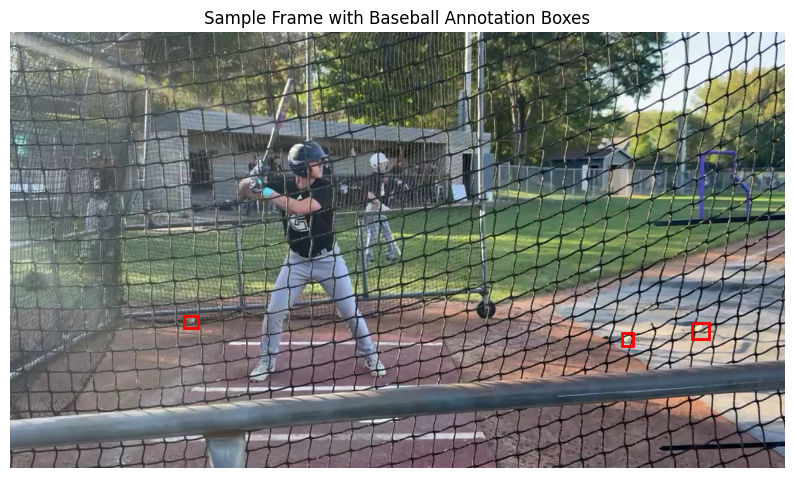

In [7]:
# Visualize one image with its annotation boxes to confirm the dataset was built correctly
sample = dataset[0]

image = Image.open(sample["image_path"])

fig, ax = plt.subplots(1, figsize=(10, 6))
ax.imshow(image)

for box in sample["boxes"]:
    xtl, ytl, xbr, ybr = box
    width = xbr - xtl
    height = ybr - ytl

    rect = patches.Rectangle(
        (xtl, ytl),
        width,
        height,
        linewidth=2,
        edgecolor="red",
        facecolor="none"
    )
    ax.add_patch(rect)

ax.set_title("Sample Frame with Baseball Annotation Boxes")
ax.axis("off")
plt.show()

In [8]:
# Split dataset into training and validation sets
train_data, val_data = train_test_split(dataset, test_size=0.2, random_state=42)

print("Training images:", len(train_data))
print("Validation images:", len(val_data))

Training images: 2256
Validation images: 564


In [9]:
# Custom PyTorch Dataset for baseball object detection
class BaseballDataset(Dataset):
    def __init__(self, data, resize_size=(640, 640)):
        self.data = data
        self.resize_size = resize_size

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]

        # Open image and convert to RGB
        image = Image.open(sample["image_path"]).convert("RGB")
        original_width, original_height = image.size

        # Resize image for faster model training
        new_width, new_height = self.resize_size
        image = image.resize((new_width, new_height))

        # Convert bounding boxes to tensor
        boxes = torch.tensor(sample["boxes"], dtype=torch.float32)

        # Scale bounding boxes to match resized image dimensions
        scale_x = new_width / original_width
        scale_y = new_height / original_height
        boxes[:, [0, 2]] *= scale_x
        boxes[:, [1, 3]] *= scale_y

        # Convert labels to tensor
        labels = torch.tensor(sample["labels"], dtype=torch.int64)

        # Convert image to PyTorch tensor
        image = F.to_tensor(image)

        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": torch.tensor([idx])
        }

        return image, target


# Create training and validation datasets
train_dataset = BaseballDataset(train_data)
val_dataset = BaseballDataset(val_data)

# Test one item from the dataset
image, target = train_dataset[0]

print("Image shape:", image.shape)
print("Boxes shape:", target["boxes"].shape)
print("Labels:", target["labels"][:10])

Image shape: torch.Size([3, 640, 640])
Boxes shape: torch.Size([25, 4])
Labels: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


In [10]:
# Custom collate function because each image may have a different number of bounding boxes
def collate_fn(batch):
    return tuple(zip(*batch))


# DataLoaders feed batches of images and annotation targets into the model
train_loader = DataLoader(
    train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=2,
    shuffle=False,
    collate_fn=collate_fn
)

# Test one batch
images, targets = next(iter(train_loader))

print("Number of images in batch:", len(images))
print("Image shape:", images[0].shape)
print("Boxes shape:", targets[0]["boxes"].shape)
print("Labels:", targets[0]["labels"][:10])

Number of images in batch: 2
Image shape: torch.Size([3, 640, 640])
Boxes shape: torch.Size([1, 4])
Labels: tensor([1])


In [11]:
# Use GPU if available; otherwise use CPU
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print("Using device:", device)

Using device: cpu


In [12]:
# Select GPU if available for faster training; otherwise fall back to CPU
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [13]:
# Load a pretrained Faster R-CNN model for object detection
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")

# The model needs two classes: background and baseball
num_classes = 2

# Replace the classification head so the model predicts baseballs instead of COCO classes
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Move model to the selected device
model.to(device)

print("Model ready on:", device)

Model ready on: cpu


In [ ]:
# Train on a small subset first so the notebook can run on a regular laptop
small_train_data = train_data[:100]
small_train_dataset = BaseballDataset(small_train_data)

small_train_loader = DataLoader(
    small_train_dataset,
    batch_size=2,
    shuffle=True,
    collate_fn=collate_fn
)

print("Small training images:", len(small_train_dataset))

In [14]:
# Use a smaller subset of the training data so the notebook runs efficiently on CPU
# This ensures the training loop executes quickly without long runtimes
small_train_data = train_data[:100]

# Create a dataset object from the smaller subset
small_train_dataset = BaseballDataset(small_train_data)

# Create a DataLoader to feed batches of images and labels into the model
small_train_loader = DataLoader(
    small_train_dataset,
    batch_size=2,   # Number of images processed per batch
    shuffle=True,   # Shuffle data for better training performance
    collate_fn=collate_fn  # Custom function to handle variable number of boxes per image
)

# Display the number of images used for this demonstration training
print("Small training images:", len(small_train_dataset))

Small training images: 100


In [15]:
# Set up the optimizer to update model parameters during training
params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.SGD(
    params,
    lr=0.005,        # Learning rate controls the step size during training
    momentum=0.9,    # Momentum helps stabilize updates
    weight_decay=0.0005  # Weight decay helps reduce overfitting
)

# Train for one epoch as a demonstration run
num_epochs = 1

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for i, (images, targets) in enumerate(small_train_loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

        if i % 10 == 0:
            print(f"Epoch {epoch+1}, Step {i}, Loss: {losses.item():.4f}")

    print(f"Epoch {epoch+1} complete. Total loss: {total_loss:.4f}")

Epoch 1, Step 0, Loss: 4.2648
Epoch 1, Step 10, Loss: 0.5995
Epoch 1, Step 20, Loss: 1.2518
Epoch 1, Step 30, Loss: 0.9139
Epoch 1, Step 40, Loss: 0.6952
Epoch 1 complete. Total loss: 42.0390


In [16]:
# Switch model to evaluation mode for prediction
model.eval()

# Take one image from validation set
test_image, test_target = val_dataset[0]

# Run prediction (no gradient needed)
with torch.no_grad():
    prediction = model([test_image.to(device)])

# Show number of predictions
print("Number of predicted boxes:", len(prediction[0]["boxes"]))
print("Top scores:", prediction[0]["scores"][:5])

Number of predicted boxes: 26
Top scores: tensor([0.8822, 0.4928, 0.4506, 0.3003, 0.2824])


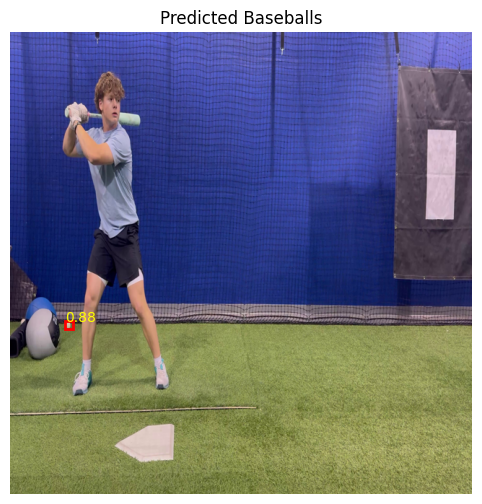

In [18]:
# Visualize prediction results

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Convert image to display format
img = test_image.permute(1, 2, 0).cpu().numpy()

fig, ax = plt.subplots(1, figsize=(8, 6))
ax.imshow(img)

# Draw only high-confidence predictions
threshold = 0.5

boxes = prediction[0]["boxes"].cpu()
scores = prediction[0]["scores"].cpu()

for box, score in zip(boxes, scores):
    if score > threshold:
        xtl, ytl, xbr, ybr = box
        rect = patches.Rectangle(
            (xtl, ytl),
            xbr - xtl,
            ybr - ytl,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(xtl, ytl, f"{score:.2f}", color='yellow')

ax.set_title("Predicted Baseballs")
ax.axis("off")
plt.show()